In [4]:
import os
import json
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import time
from collections import defaultdict
import random

import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [5]:

def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    #Python random
    random.seed(seed)

    # NumPy random
    np.random.seed(seed)

    # PyTorch random
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # For deterministic behavior (slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # For DataLoader workers
    os.environ['PYTHONHASHSEED'] = str(seed)

    print(f"🌱 All random seeds set to: {seed}")
    print("✅ Training will now be reproducible!")

# รันทันที!
set_seed(42)

🌱 All random seeds set to: 42
✅ Training will now be reproducible!


In [6]:
# STEP 0 — mount (ทำครั้งเดียวต่อ session)
from google.colab import drive
drive.mount('/content/drive')

# STEP 1 — ตรวจว่าพาธถูกจริงไหม
!ls "/content/drive/MyDrive/Project Deeplearning/TACO" | head

# STEP 2 — ถ้ารายการโผล่ถูก ให้รันโค้ดต่อได้เลย
from pathlib import Path, PurePosixPath
ANN_FILE = Path("/content/drive/MyDrive/Project Deeplearning/TACO/train_annotations.json")
print("exists?", ANN_FILE.exists())        # ต้องขึ้น True

with open(ANN_FILE, "r") as f:
    taco_json = json.load(f)
category_map = {c["id"]: c["name"] for c in taco_json["categories"]}
print("✓ loaded", len(category_map), "classes")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
annotations.json
batch_1
batch_10
batch_11
batch_12
batch_13
batch_14
batch_15
batch_2
batch_3
exists? True
✓ loaded 60 classes


In [7]:
# สมมติเราเซ็ต ROOT ไว้แล้วในเซลล์ถัดไปว่า
ROOT = Path("/content/drive/MyDrive/Project Deeplearning/TACO")

from pathlib import Path

ANN_FILE = Path("/content/drive/MyDrive/Project Deeplearning/TACO/train_annotations.json")
# หรือจะใช้ SPLITS["train"] ภายหลังก็ได้

with open(ANN_FILE) as f:
    taco_json = json.load(f)

category_map = {cat['id']: cat['name'] for cat in taco_json['categories']}
print(f"✓ category_map loaded — {len(category_map)} classes")


✓ category_map loaded — 60 classes


In [8]:
from torch.utils.data import Dataset
class TacoDataset(Dataset):
    def __init__(self, root, annotations: dict, transforms=None):
        self.root       = root                      # Path/str ของโฟลเดอร์รูป
        self.transforms = transforms
        self.annos      = annotations["annotations"]
        self.images     = annotations["images"]
        self.id2img     = {img["id"]: img for img in self.images}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.root, img_info["file_name"])
        image    = Image.open(img_path).convert("RGB")

        # ----- annotations ของภาพนี้ -----
        annos = [a for a in self.annos if a["image_id"] == img_info["id"]]

        boxes, labels = [], []
        for a in annos:
            x, y, w, h = a["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(a["category_id"])

        boxes  = torch.as_tensor(boxes,  dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes":    boxes,
            "labels":   labels,
            "image_id": torch.tensor([img_info["id"]]),   # ใช้ id จริง
            "area":     (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
            "iscrowd":  torch.zeros((len(boxes),), dtype=torch.int64),
        }

        # ---- transforms ----
        if self.transforms:
            image = self.transforms(image)
        # ถ้า transforms ไม่ได้แปลงเป็น tensor ให้ทำ
        if not isinstance(image, torch.Tensor):
            image = F.to_tensor(image)

        return image, target



In [ ]:

from torchvision.transforms import functional as F
from torch.utils.data import DataLoader

ROOT = "/content/drive/MyDrive/Project Deeplearning/TACO"

# --- train ---
with open(f"{ROOT}/train_annotations.json") as f:
    train_json = json.load(f)

train_dataset = TacoDataset(
    root=f"{ROOT}/train",
    annotations=train_json,
    transforms=lambda img: F.to_tensor(img),
)

# --- val ---
with open(f"{ROOT}/val_annotations.json") as f:
    val_json = json.load(f)

val_dataset = TacoDataset(
    root=f"{ROOT}/val",
    annotations=val_json,
    transforms=lambda img: F.to_tensor(img),
)

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=2,
                          shuffle=True,  collate_fn=collate_fn, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=1,
                          shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f"train: {len(train_dataset)} • val: {len(val_dataset)}")



In [12]:
# เพิ่ม cell ใหม่หลังจาก cell ที่สร้าง TacoDataset
import json                           # ← ถ้ายังไม่ใส่
import torchvision.transforms as T
import random

class EnhancedTransforms:
    def __init__(self, train=True):
        self.train = train

    def __call__(self, image):
        if self.train:
            # Random horizontal flip
            if random.random() < 0.5:
                image = F.hflip(image)

            # Color jittering (เล็กน้อยเพื่อไม่ให้ดูไม่เป็นธรรมชาติ)
            if random.random() < 0.3:
                image = T.ColorJitter(
                    brightness=0.15,
                    contrast=0.15,
                    saturation=0.15
                )(image)

        # Convert to tensor
        return F.to_tensor(image)

# สร้าง dataset ใหม่ที่มี augmentation ดีขึ้น
train_dataset_enhanced = TacoDataset(
    root=f"{ROOT}/train",
    annotations=train_json,
    transforms=EnhancedTransforms(train=True)
)

val_dataset_enhanced = TacoDataset(
    root=f"{ROOT}/val",
    annotations=val_json,
    transforms=EnhancedTransforms(train=False)
)

# DataLoader ที่ปรับปรุง
train_loader_enhanced = DataLoader(
    train_dataset_enhanced, batch_size=2, shuffle=True,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)

val_loader_enhanced = DataLoader(
    val_dataset_enhanced, batch_size=1, shuffle=False,
    collate_fn=collate_fn, num_workers=2, pin_memory=True
)

print("✅ Enhanced data augmentation ready!")
print(f"   Train: {len(train_dataset_enhanced)} samples")
print(f"   Val: {len(val_dataset_enhanced)} samples")

✅ Enhanced data augmentation ready!
   Train: 1050 samples
   Val: 225 samples


In [13]:
import torch, torchvision
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_model(num_classes: int):
    # ── 1) load pretrained Faster-R-CNN-V2 ────────────────────────────
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1
    model   = fasterrcnn_resnet50_fpn_v2(weights=weights)

    # ── 2) replace the classifier head ────────────────────────────────
    in_feat = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, num_classes)

    # ── 3) partial fine-tuning  (unfreeze layer4 ของ backbone) ────────
    for p in model.backbone.parameters():
        p.requires_grad_(False)

    for name, p in model.backbone.body.named_parameters():
        if "layer4" in name:
            p.requires_grad_(True)

    return model.to(device)

# -------- create model --------
num_classes = len(category_map) + 1     # +1 background
model = get_model(num_classes)


In [14]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ── เตรียม COCO ground-truth ของ val set (ทำครั้งเดียว) ──
coco_gt = COCO(f"{ROOT}/val_annotations.json")   # ← path val json

# เพิ่ม cell ใหม่หลังจาก evaluate_map function เดิม
def enhanced_evaluate_map(model, data_loader, device, coco_gt, category_map, conf_threshold=0.5):
    """Enhanced evaluation with detailed metrics"""
    model.eval()
    results = []
    total_predictions = 0

    print(f"🔍 Running evaluation with confidence threshold: {conf_threshold}")

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluating", leave=False):
            images = [img.to(device) for img in images]
            outputs = model(images)

            for tgt, out in zip(targets, outputs):
                img_id = int(tgt["image_id"].item())

                boxes = out["boxes"].cpu()
                scores = out["scores"].cpu()
                labels = out["labels"].cpu()

                # Filter by confidence
                keep = scores > conf_threshold
                boxes = boxes[keep]
                scores = scores[keep]
                labels = labels[keep]

                total_predictions += len(boxes)

                # Convert xyxy to xywh
                if len(boxes) > 0:
                    boxes[:, 2:] -= boxes[:, :2]

                    for box, score, label in zip(boxes, scores, labels):
                        results.append({
                            "image_id": img_id,
                            "category_id": int(label.item()),
                            "bbox": [round(x, 2) for x in box.tolist()],
                            "score": float(score.item()),
                        })

    print(f"   Total predictions: {total_predictions}")

    if not results:
        print("⚠️ No predictions above confidence threshold")
        return 0.0, 0.0, {}

    # COCO evaluation
    try:
        coco_gt.dataset.setdefault("info", {})
        coco_dt = coco_gt.loadRes(results)
        coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()

        map_50_95 = coco_eval.stats[0]  # mAP@0.5:0.95
        map_50 = coco_eval.stats[1]     # mAP@0.5

        return map_50_95, map_50, results

    except Exception as e:
        print(f"⚠️ Evaluation error: {e}")
        return 0.0, 0.0, {}

# ฟังก์ชันวิเคราะห์ per-class
def analyze_class_performance(results, category_map):
    """Analyze per-class detection performance"""
    if not results:
        return {}

    class_counts = {}
    for result in results:
        cat_id = result['category_id']
        cat_name = category_map.get(cat_id, f"Unknown_{cat_id}")
        class_counts[cat_name] = class_counts.get(cat_name, 0) + 1

    # Sort by count
    sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

    print("\n📊 Detection Count by Class (Top 15):")
    print("-" * 45)
    for i, (class_name, count) in enumerate(sorted_classes[:15]):
        print(f"{i+1:2d}. {class_name:<25} {count:4d} detections")

    return class_counts

print("✅ Enhanced evaluation functions ready!")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
✅ Enhanced evaluation functions ready!


In [15]:
params = [p for p in model.parameters() if p.requires_grad]   # <– ย้ำให้มีตัวแปรนี้
optimizer = optim.SGD(params, lr=0.05, momentum=0.9, weight_decay=0.005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm   # (ติดตั้ง tqdm ไปแล้ว)


# เพิ่ม cell ใหม่แทนที่ training loop เดิม
from torch.optim.lr_scheduler import ReduceLROnPlateau
import os

# สร้างโฟลเดอร์สำหรับ checkpoints
checkpoint_dir = f"{ROOT}/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Setup ใหม่สำหรับ optimizer และ scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.01, momentum=0.9, weight_decay=0.0005)

# ใช้ ReduceLROnPlateau แทน StepLR
lr_scheduler = ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3,
    verbose=True, min_lr=1e-6, threshold=0.001
)

# ตัวแปรสำหรับ tracking
num_epochs = 25
loss_hist, map_hist, map50_hist, lr_hist = [], [], [], []
best_map = 0.0
best_map50 = 0.0
patience_counter = 0
early_stop_patience = 7

print("🚀 Starting improved training with enhanced features...")
print(f"   Epochs: {num_epochs}")
print(f"   Early stopping patience: {early_stop_patience}")
print(f"   Checkpoint directory: {checkpoint_dir}")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    epoch_start_time = time.time()

    # Training phase
    pbar = tqdm(train_loader_enhanced, desc=f"E{epoch+1:2d}/{num_epochs}")

    for batch_idx, (images, targets) in enumerate(pbar):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass
        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += losses.item()

        # Update progress bar
        pbar.set_postfix({
            'Loss': f'{losses.item():.4f}',
            'Avg': f'{running_loss/(batch_idx+1):.4f}',
            'LR': f'{optimizer.param_groups[0]["lr"]:.1e}'
        })

        # Memory cleanup
        if (batch_idx + 1) % 50 == 0:
            torch.cuda.empty_cache()

    # Calculate metrics
    avg_loss = running_loss / len(train_loader_enhanced)
    epoch_time = time.time() - epoch_start_time

    # Evaluation phase
    print(f"\n[Epoch {epoch+1}] Evaluating... ", end="")
    eval_start = time.time()

    map5095, map50, eval_results = enhanced_evaluate_map(
        model, val_loader_enhanced, device, coco_gt, category_map
    )

    eval_time = time.time() - eval_start

    # บันทึกประวัติ (แก้ไขปัญหาจากโค้ดเดิม)
    loss_hist.append(avg_loss)
    map_hist.append(map5095)
    map50_hist.append(map50)
    lr_hist.append(optimizer.param_groups[0]['lr'])

    # Update learning rate (แก้ไขลำดับจากโค้ดเดิม)
    lr_scheduler.step(map5095)

    # Display results
    print(f"\n[Epoch {epoch+1:2d}] "
          f"Loss: {avg_loss:.4f} | "
          f"mAP@0.5:0.95: {map5095:.4f} | "
          f"mAP@0.5: {map50:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.1e}")
    print(f"            "
          f"Train time: {epoch_time:.1f}s | "
          f"Eval time: {eval_time:.1f}s")

    # Model checkpointing
    is_best_map = map5095 > best_map
    is_best_map50 = map50 > best_map50

    if is_best_map:
        best_map = map5095
        patience_counter = 0

        # Save best model
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': lr_scheduler.state_dict(),
            'best_map': best_map,
            'best_map50': best_map50,
            'loss_hist': loss_hist,
            'map_hist': map_hist,
            'map50_hist': map50_hist,
            'lr_hist': lr_hist,
            'category_map': category_map,
            'num_classes': num_classes
        }

        torch.save(checkpoint, f'{checkpoint_dir}/best_model_map.pth')
        print(f"✅ New best mAP@0.5:0.95 model saved! ({best_map:.4f})")
    else:
        patience_counter += 1

    if is_best_map50:
        best_map50 = map50
        torch.save(checkpoint, f'{checkpoint_dir}/best_model_map50.pth')
        print(f"✅ New best mAP@0.5 model saved! ({best_map50:.4f})")

    # Analyze detections every 5 epochs
    if (epoch + 1) % 5 == 0 and eval_results:
        analyze_class_performance(eval_results, category_map)

    # Regular checkpoint
    if (epoch + 1) % 5 == 0:
        torch.save(checkpoint, f'{checkpoint_dir}/checkpoint_epoch_{epoch+1}.pth')
        print(f"💾 Regular checkpoint saved (epoch {epoch+1})")

    # Early stopping
    if patience_counter >= early_stop_patience:
        print(f"\n🛑 Early stopping triggered after {epoch+1} epochs")
        print(f"   No improvement in mAP@0.5:0.95 for {early_stop_patience} epochs")
        break

    print("-" * 70)

print(f"\n🎉 Training completed!")
print(f"   Best mAP@0.5:0.95: {best_map:.4f}")
print(f"   Best mAP@0.5: {best_map50:.4f}")
print(f"   Total epochs: {len(loss_hist)}")

# Clear memory
torch.cuda.empty_cache()


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


🚀 Starting improved training with enhanced features...
   Epochs: 25
   Early stopping patience: 7
   Checkpoint directory: /content/drive/MyDrive/Project Deeplearning/TACO/checkpoints


E 1/25:   6%|▌         | 32/525 [00:23<05:23,  1.52it/s, Loss=0.9525, Avg=1.5616, LR=1.0e-02]

<ipython-input-22-2e9b560d0d6a>:66: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-22-2e9b560d0d6a>:66: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-22-2e9b560d0d6a>:66: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-22-2e9b560d0d6a>:70: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{ROOT}/training_progress_{timestamp}.png', dpi=300, bbox_inches='tight')
<ipython-input-22-2e9b560d0d6a>:70: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{ROOT}/training_progress_{timestamp}.png', dpi=300, bbox_inches='tight')
<ipython-input-22-2e9b560d0d6a>:70: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS 

📊 Training progress plot saved: training_progress_20250610_064259.png


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


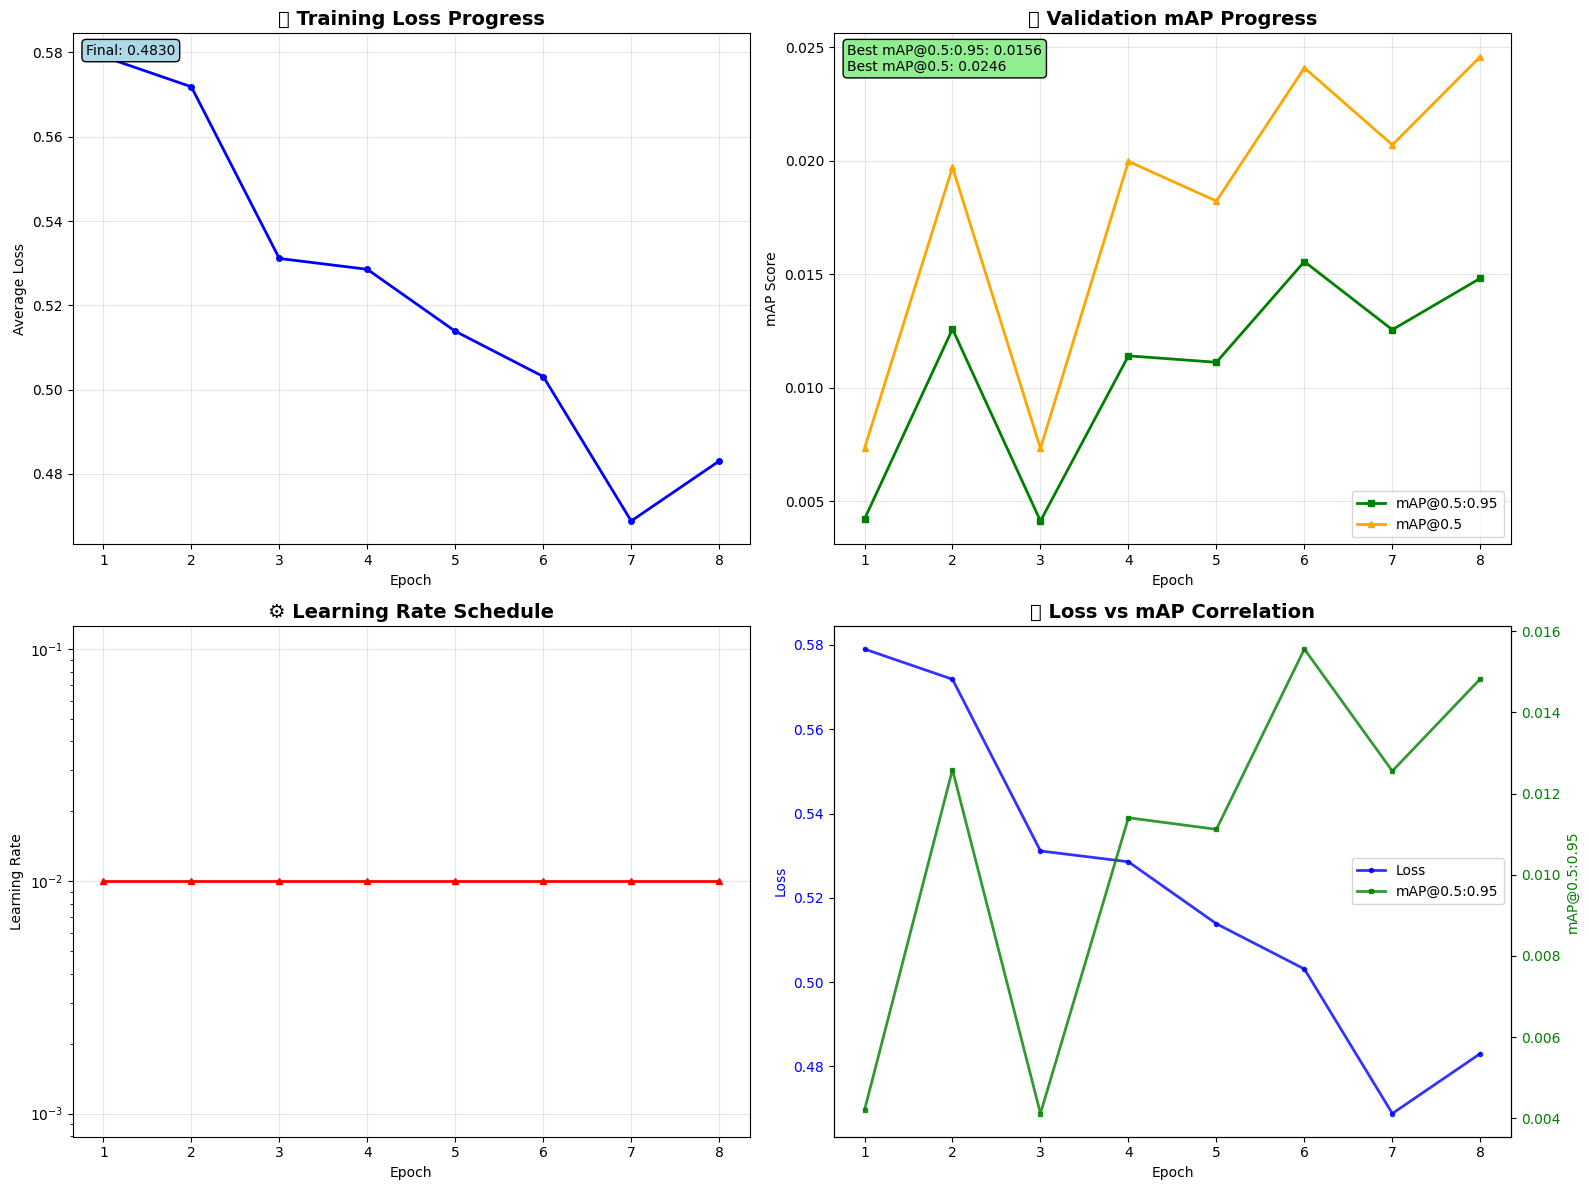

In [22]:
# Cell ใหม่ที่ 4: Enhanced Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import time

def plot_enhanced_training_progress(loss_hist, map_hist, map50_hist, lr_hist):
    """Enhanced training progress visualization"""

    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    epochs = range(1, len(loss_hist) + 1)

    # Loss plot with trend
    axes[0, 0].plot(epochs, loss_hist, 'b-', marker='o', linewidth=2, markersize=4)
    axes[0, 0].set_title('📉 Training Loss Progress', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Average Loss')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].text(0.02, 0.98, f'Final: {loss_hist[-1]:.4f}',
                    transform=axes[0, 0].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue'))

    # mAP comparison
    axes[0, 1].plot(epochs, map_hist, 'g-', marker='s', linewidth=2,
                   markersize=4, label='mAP@0.5:0.95')
    axes[0, 1].plot(epochs, map50_hist, 'orange', marker='^', linewidth=2,
                   markersize=4, label='mAP@0.5')
    axes[0, 1].set_title('📈 Validation mAP Progress', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('mAP Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].text(0.02, 0.98, f'Best mAP@0.5:0.95: {max(map_hist):.4f}\nBest mAP@0.5: {max(map50_hist):.4f}',
                    transform=axes[0, 1].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen'))

    # Learning rate schedule
    axes[1, 0].plot(epochs, lr_hist, 'r-', marker='^', linewidth=2, markersize=4)
    axes[1, 0].set_title('⚙️ Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_yscale('log')
    axes[1, 0].grid(True, alpha=0.3)

    # Combined metrics
    ax2 = axes[1, 1]
    ax3 = ax2.twinx()

    line1 = ax2.plot(epochs, loss_hist, 'b-', marker='o', linewidth=2,
                    markersize=3, label='Loss', alpha=0.8)
    line2 = ax3.plot(epochs, map_hist, 'g-', marker='s', linewidth=2,
                    markersize=3, label='mAP@0.5:0.95', alpha=0.8)

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss', color='blue')
    ax3.set_ylabel('mAP@0.5:0.95', color='green')
    ax2.set_title('🔄 Loss vs mAP Correlation', fontsize=14, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax3.tick_params(axis='y', labelcolor='green')

    # Legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax2.legend(lines, labels, loc='center right')

    plt.tight_layout()

    # Save plot
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    plt.savefig(f'{ROOT}/training_progress_{timestamp}.png', dpi=300, bbox_inches='tight')
    print(f"📊 Training progress plot saved: training_progress_{timestamp}.png")
    plt.show()

# เรียกใช้ฟังก์ชันนี้หลังจากการฝึกเสร็จ
if len(loss_hist) > 0:  # ตรวจสอบว่ามีข้อมูลแล้ว
    plot_enhanced_training_progress(loss_hist, map_hist, map50_hist, lr_hist)
else:
    print("⚠️ No training history to plot yet. Run training first!")